We will use matchwise stats as training set for clustering model.

## Using K Means Clustering

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd


df = pd.read_csv(r"../data/matchwise_processed.csv")

df.head()

,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,team,xg_per_shot,carries_per_pass
0,537,11,20.786734,3.128655,-0.042155,-0.046114,-0.023094,Argentina,0.098427,0.769088
1,659,19,21.512906,2.338624,-0.034995,-0.128787,1.816389,Colombia,0.052009,0.799697
2,378,19,21.140958,2.108844,-0.107044,0.033943,-0.629554,Canada,0.326595,0.759259
3,365,16,23.869265,1.385417,-0.124896,0.032662,0.152638,Uruguay,0.290652,0.794521
4,460,11,21.812680,1.252688,-0.147674,-0.093207,-0.566419,Uruguay,0.068597,0.791304


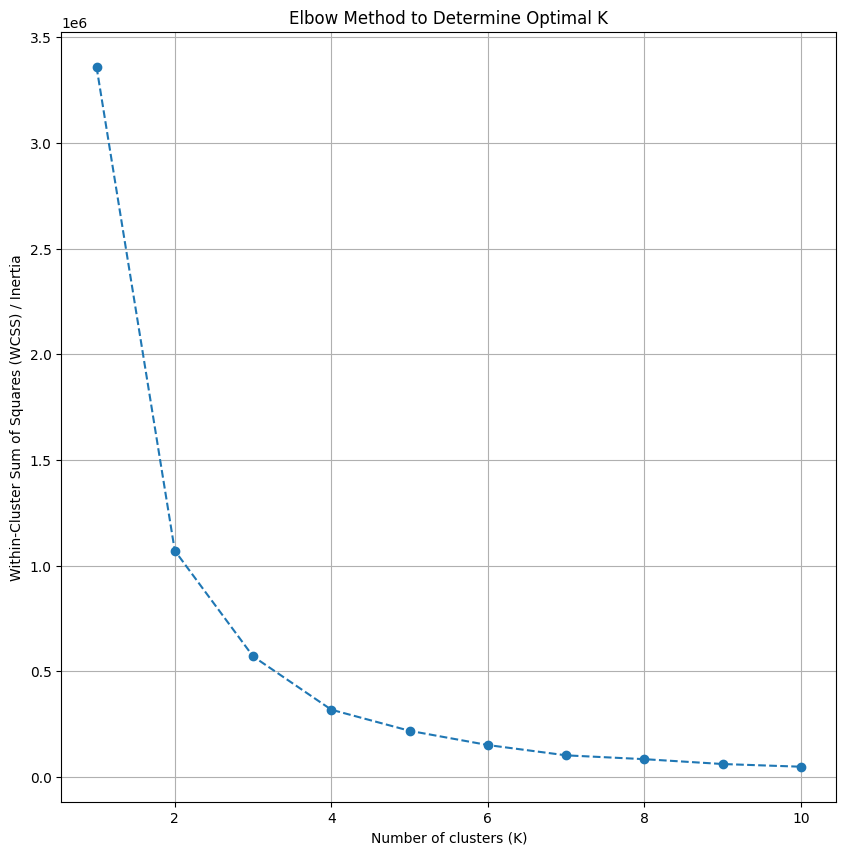

In [2]:
wcss = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df.drop(columns=['team']))
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS) / Inertia")
plt.title("Elbow Method to Determine Optimal K")
plt.grid(True)
plt.show()

4~5 seems to be the optimum K value for K Means Clustering

We will choose **k=5**

In [3]:
X = df.drop(columns=['team'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=42)
X["cluster"] = kmeans.fit_predict(X_scaled)

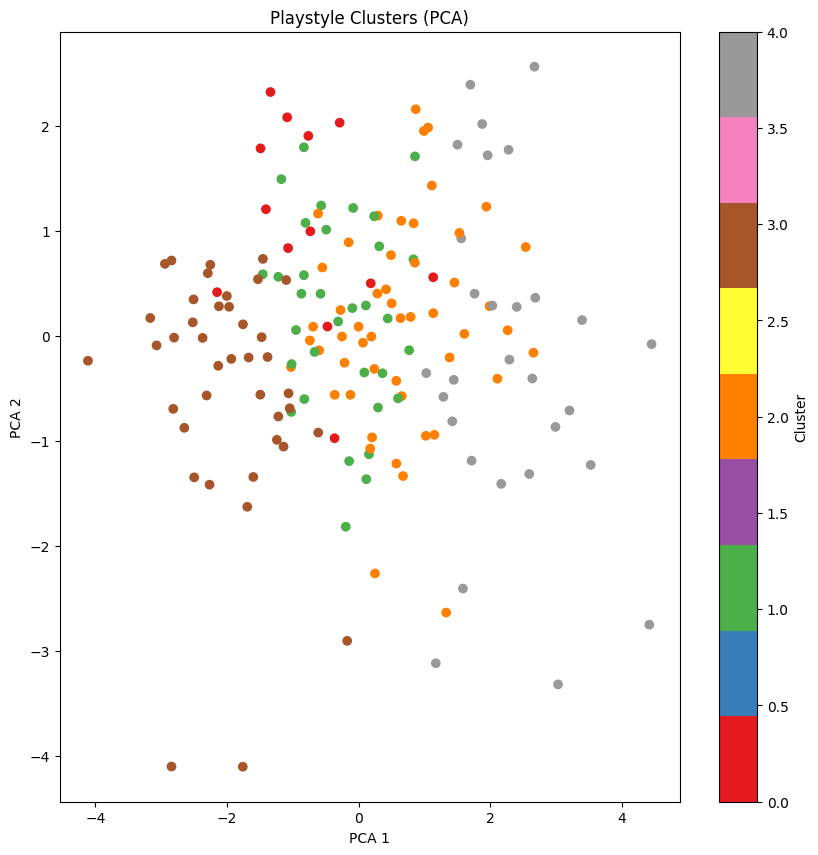

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# assuming X_scaled already exists
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,10))
plt.scatter(X_pca[:,0], X_pca[:,1], c=X["cluster"], cmap="Set1")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Playstyle Clusters (PCA)")
plt.colorbar(label="Cluster")
plt.show()

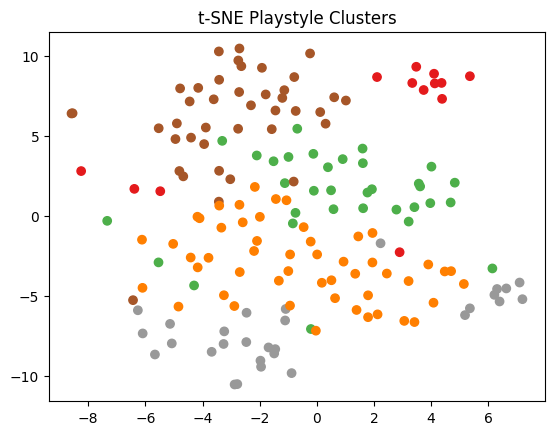

In [6]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=X["cluster"], cmap="Set1")
plt.title("t-SNE Playstyle Clusters")
plt.show()

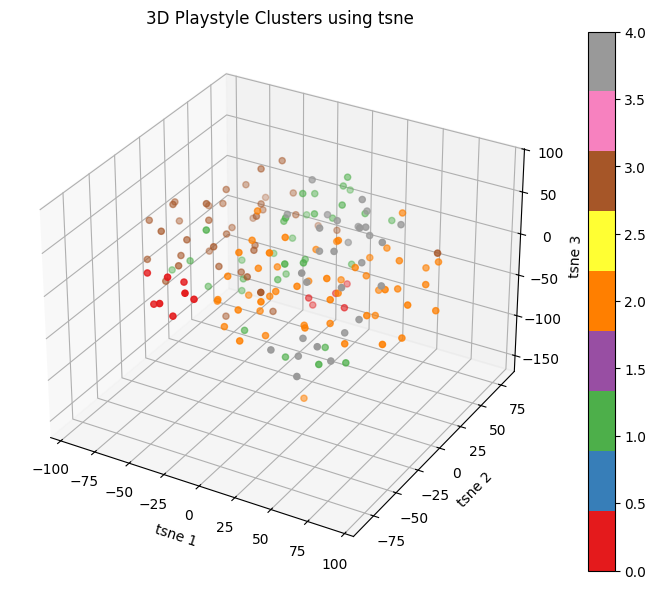

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Reduce to 3 components
tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne_3d = tsne.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_tsne_3d[:,0],
    X_tsne_3d[:,1],
    X_tsne_3d[:,2],
    c=X["cluster"],
    cmap="Set1"
)

ax.set_xlabel("tsne 1")
ax.set_ylabel("tsne 2")
ax.set_zlabel("tsne 3")
ax.set_title("3D Playstyle Clusters using tsne")

fig.colorbar(scatter, ax=ax)
plt.show()

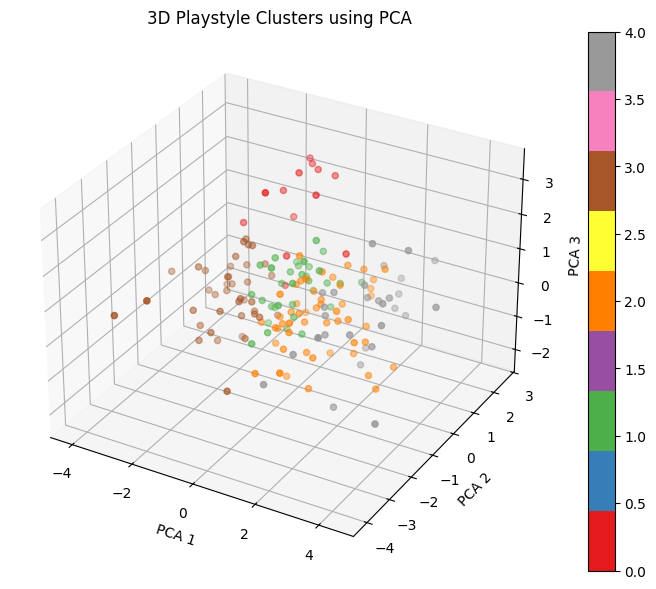

In [8]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 3 components
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=X["cluster"],
    cmap="Set1"
)

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D Playstyle Clusters using PCA")

fig.colorbar(scatter, ax=ax)
plt.show()

In [10]:
import plotly.express as px

fig = px.scatter_3d(
    x=X_pca_3d[:,0],
    y=X_pca_3d[:,1],
    z=X_pca_3d[:,2],
    color=X["cluster"].astype(str),
    hover_name=df["team"],
    title="3D Playstyle Clusters using PCA"
)

fig.show()

In [12]:
fig = px.scatter_3d(
    x=X_tsne_3d[:,0],
    y=X_tsne_3d[:,1],
    z=X_tsne_3d[:,2],
    color=X["cluster"].astype(str),
    hover_name=df["team"],
    title="3D Playstyle Clusters using t-SNE"
)

fig.show()

In [13]:
cluster_summary = X.groupby("cluster").mean()
cluster_summary

,passes,shots,average_pass_length,ppda,avg_pass_angle_deep,avg_pass_angle_mid,avg_pass_angle_final,xg_per_shot,carries_per_pass
cluster,,,,,,,,,
0,386.076923,13.923077,22.558914,2.160060,-0.001960,-0.099663,-0.245953,0.283487,0.780563
1,469.333333,11.787879,21.364624,2.364003,-0.140255,-0.080364,0.285805,0.085173,0.795691
2,550.019608,13.039216,20.428885,2.623907,0.119780,0.040859,-0.921027,0.103544,0.816374
3,342.225000,8.250000,23.880916,2.634946,0.019414,-0.098622,0.056122,0.083211,0.725391
4,672.965517,19.482759,18.735789,3.120462,-0.036849,-0.069129,0.657826,0.103200,0.850918


# Clusters Found

## Cluster 0 - Clinical Transition Play

- Moderate in almost all categories
- Want to play balanced and not focus heavily on one type of gameplay
- These teams don't need much of the ball (386 passes), but they make every second count. A $0.28$ xG per shot is incredibly high, meaning they aren't taking speculative long-range strikes. They wait for the perfect moment to break.

## Cluster 1 - Vertical Heavy Metal

- Direct, high energy attacking
- This sits between the extremes. They have a solid passing base (469) but a very positive pass angle in the final third (0.285).

## Cluster 2 - Conservative Possessional Play

- Risk-Averse Play
- With a healthy 550 passes but a significant negative pass angle in the final third (-0.92), these teams prioritize ball retention over penetration. 
- If a gap doesn't open up immediately, they are happy to recycle the ball back to the defenders to reset. It’s "safe" football designed to tire out the opponent.

## Cluster 3 - Haramball / Low Block

- Based on Survival and Directness
- This is the most "pragmatic" cluster. They have the lowest pass volume (342) and the longest average pass length (23.8). Instead of building through the midfield, they bypass it entirely with long balls. 
- They focus on a deep defensive block and hope to capitalize on set pieces or rare errors.

## Cluster 4 - Modern Tiki-Taka

- Complete pitch dominance
- This is the gold standard for possession-based football. With the highest volume of passes (672) and the shortest average pass length (18.7), this cluster represents teams that use short, intricate triangles to dismantle a defense.
- The high PPDA (Passes Per Defensive Action) suggests an aggressive high press, winning the ball back immediately to restart the cycle.

In [17]:
labels = {
    0: "Clinical Transition Play",
    1: "Vertical",
    2: "Possessional Play",
    3: "Haramball",
    4: "Tiki-Taka"
}

X["playstyle"] = X["cluster"].map(labels)

X.to_csv(r"../data/cluster_data.csv", index=False)

Now we go on and classify team averages into clusters and do some data exploration